### Define libraries and load data
These are the first steps to load the required libraries and the data. As I work in Colab sometimes, there are also some (commented) steps for running the code in Colab. You need to adjust the data directories below to run the notebook. 

In [ ]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
# Load Python libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

In [2]:
# Load data

# Define the data directory path
data_dir = '/home/nikk/GitHubProjects/kaggle_projects/kaggle_titanic/data'
#data_dir = '/content/drive/MyDrive/Titanic'

# Define Random State
random_state = 12

# Load the training dataset
train_path = os.path.join(data_dir, 'train.csv')
train_df = pd.read_csv(train_path)

# Load the test dataset
test_path = os.path.join(data_dir, 'test.csv')
test_df = pd.read_csv(test_path)

### Data profiling and missing values fixing
At first, I run a quick review on a sample of rows and do some profiling on the data to get insights and identify missing and invalid values.

In [3]:
# We use this funtion to review data types, nulls, min-max values (to help us find invalid values)
def data_profiling(ds):
    numeric_columns = ds.select_dtypes(include=['int64', 'float64']).columns
    profiling_ds = pd.DataFrame({
        'data_type': ds.dtypes,
        'null_pct': ds.isnull().mean() * 100,
        'min_numeric_value': ds[numeric_columns].min(),
        'max_numeric_value': ds[numeric_columns].max()
    })
    print(f"\nProfiling analysis:\n")
    print(profiling_ds)

In [4]:
# Quick review and profiling on training data
print('\nTraining data\nReview:\n')
print(train_df.head(10))
data_profiling(train_df)

# Quick profiling on testing data
print('\nTesting data')
data_profiling(test_df)


Training data
Review:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, M

We have 4 features that need some type of correction:
1. **Embarked** => As only a few values are missing, we go with MODE.
2. **Cabin** => We will consider null values as an indication that the passenger didn't have a cabin. There are cases that under the same ticket some passengers do have a cabin and some don't (e.g. tickets 2668, PC 17608, 113781). As this happens almost always for 1st class ticket, we will assume that some high class families had their servants with them (but didn't share their cabin). We will also extract the **Deck** of the cabin.
3. **Age** => As 20% of the values are missing, we will try to build a linear model to fill the gaps. For this reason we will create a new variable called **Title**, which we will extract out of the Name feature.
4. **Fare** => We consider invalid both null and zero values. We will fix the values by using the average fare on a combination of features that seem logical to have an impact on the ticket value (Pclass, Sex and if the passenger has a cabin or not).

The same ticket can exist in both training and testing datasets (e.g. PC 17599). For this reason, we will build a unified dataset (to secure that any grouping will work correctly). At later steps we will split the dataset into training and testing again.

In [5]:
# Extract combined dataset
tr = train_df.drop(['Survived'], axis=1)
tr['IsTrain'] = 1
ts = test_df.copy()
ts['IsTrain'] = 0
combined_ds = pd.concat([tr, ts], ignore_index=False)

In [6]:
# Fix null values for Embarked
combined_ds['Embarked'] = combined_ds['Embarked'].fillna(combined_ds['Embarked'].mode()[0])

# Create flag for passengers with cabin
combined_ds['HasCabin'] = combined_ds['Cabin'].apply(lambda x: 1 if pd.notna(x) else 0)
combined_ds['Deck'] = combined_ds['Cabin'].apply(lambda x: min(t[0] for t in str(x).split()) if pd.notna(x) else "No_Deck")

# Create Title feature out of the Name
combined_ds['Title'] = combined_ds['Name'].apply(lambda x: x.split(',')[1]).str.extract(' ([A-Za-z]+).', expand=False)
combined_ds['Title'] = combined_ds['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Sir', 'Rev', 'Jonkheer', 'Dona', 'the'], 'Entitled')
combined_ds['Title'] = combined_ds['Title'].replace('Mlle', 'Miss')
combined_ds['Title'] = combined_ds['Title'].replace('Ms', 'Miss')
combined_ds['Title'] = combined_ds['Title'].replace('Mme', 'Mrs')

# Fix Fare values
combined_ds['Fare'] = combined_ds['Fare'].apply(lambda x: x if pd.notna(x) and x!=0 else None) # turn 0 to None, so that it will be ignored by Mean
combined_ds['estFare'] = combined_ds.groupby(['Pclass', 'Sex', 'HasCabin'])['Fare'].transform(lambda x: round(x.median(),4))
combined_ds['Fare'] = combined_ds.apply(lambda row: row['estFare'] if pd.isna(row['Fare']) else row['Fare'], axis=1)

# Turn Sex values to numeric
label_sex = {'male':0, 'female':1}
combined_ds['SexFlg'] = combined_ds['Sex'].map(label_sex)

In [7]:
# Build a simple linear model, using features with defined Age
scaler = StandardScaler()
age_model_cat_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'HasCabin']
age_model_num_features = ['SibSp', 'Parch', 'Fare']
age_model_features = age_model_cat_features + age_model_num_features
age_model_X = combined_ds[combined_ds['Age'].notna()][age_model_features]
age_model_y = combined_ds[combined_ds['Age'].notna()]['Age']
age_model_X = pd.get_dummies(age_model_X, columns=['Pclass', 'Sex', 'Embarked', 'Title'], drop_first=False, dtype=int)
age_model_X[age_model_num_features] = scaler.fit_transform(age_model_X[age_model_num_features])
X_train, X_test, y_train, y_test = train_test_split(age_model_X, age_model_y, test_size=0.3, random_state=random_state)
model = LinearRegression()
model.fit(X_train, y_train)

# Apply the predictions into the combined dataset and fix null Age values
X = pd.get_dummies(combined_ds[age_model_features], columns=['Pclass', 'Sex', 'Embarked', 'Title'], drop_first=False, dtype=int)
X[age_model_num_features] = scaler.fit_transform(X[age_model_num_features])
combined_ds['estAge'] = model.predict(X).round()
combined_ds['Age'] = combined_ds.apply(lambda row: row['estAge'] if pd.isna(row['Age']) else row['Age'], axis=1)

### Data exploration
At this step we go through some data visualizations to get a some more insights on the data. We break our features into numerical and categorical and use different visualizations for each type. Some major findings of this task are:
- Having a small family or some companion offers a better chance of survival than when traveling alone or in a big group/family.
- A lower fare or class seems to correlate with lower chances of survival.
- Females (especially those in families) had a higher chance to survive.
- Having a cabin was also a good thing!

In [8]:
# Create exploration dataset
cat_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'HasCabin', 'Deck']
num_features = ['SibSp', 'Parch', 'Age', 'Fare']
features = cat_features + num_features + ['PassengerId']
explore_ds = combined_ds[combined_ds['IsTrain']==1][features]
explore_ds['Survived'] = train_df['Survived']
target_name = 'Survived'
target = train_df[target_name]

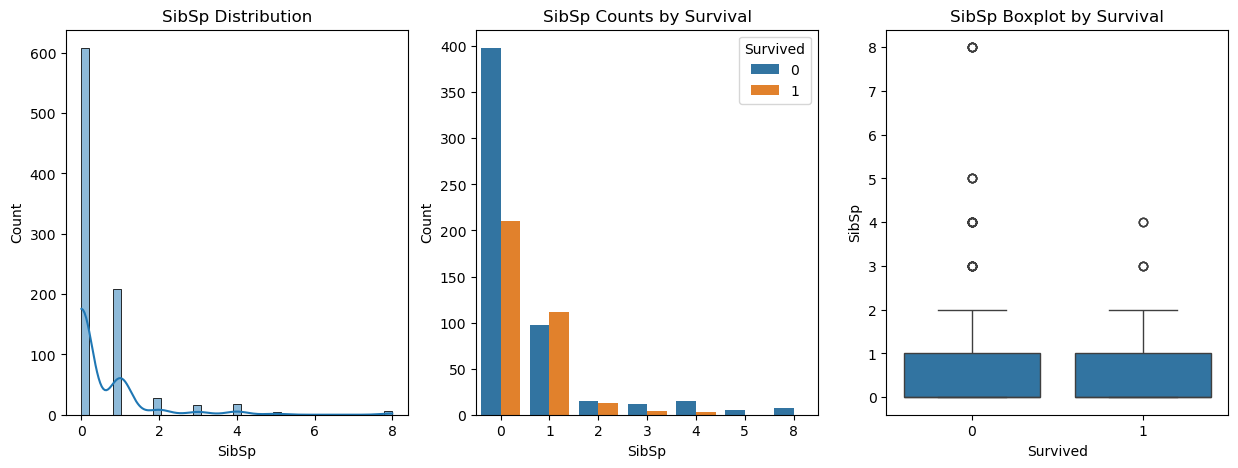

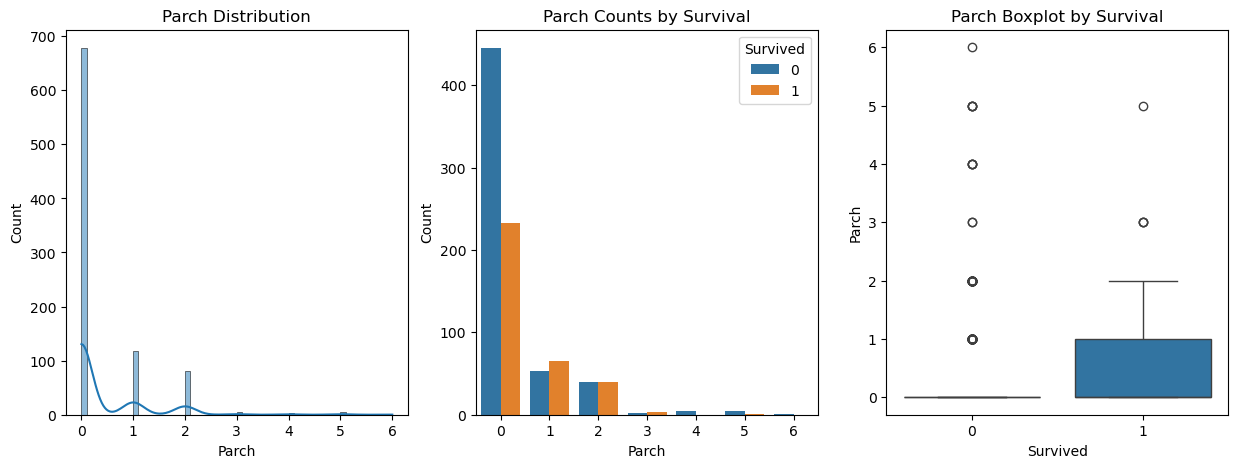

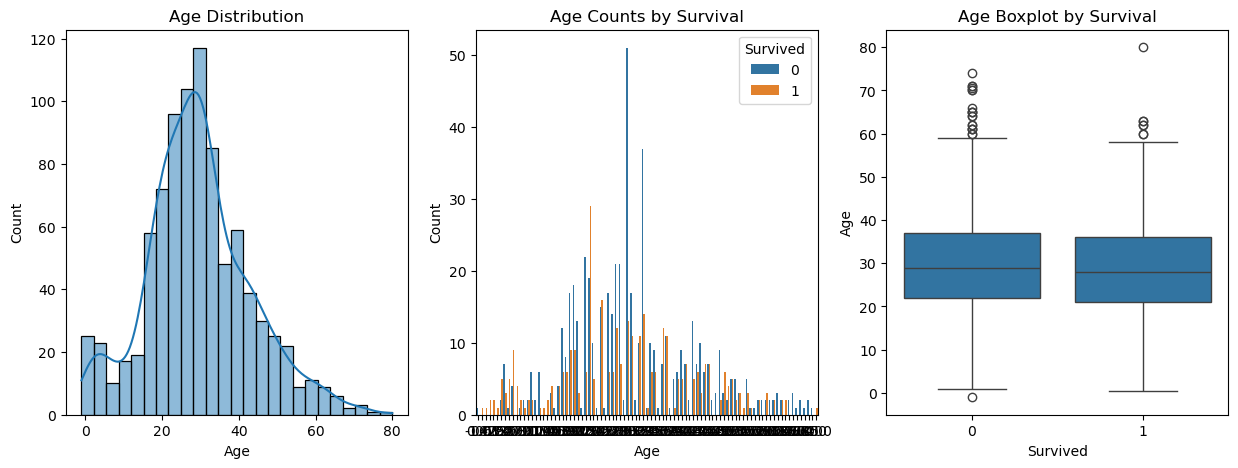

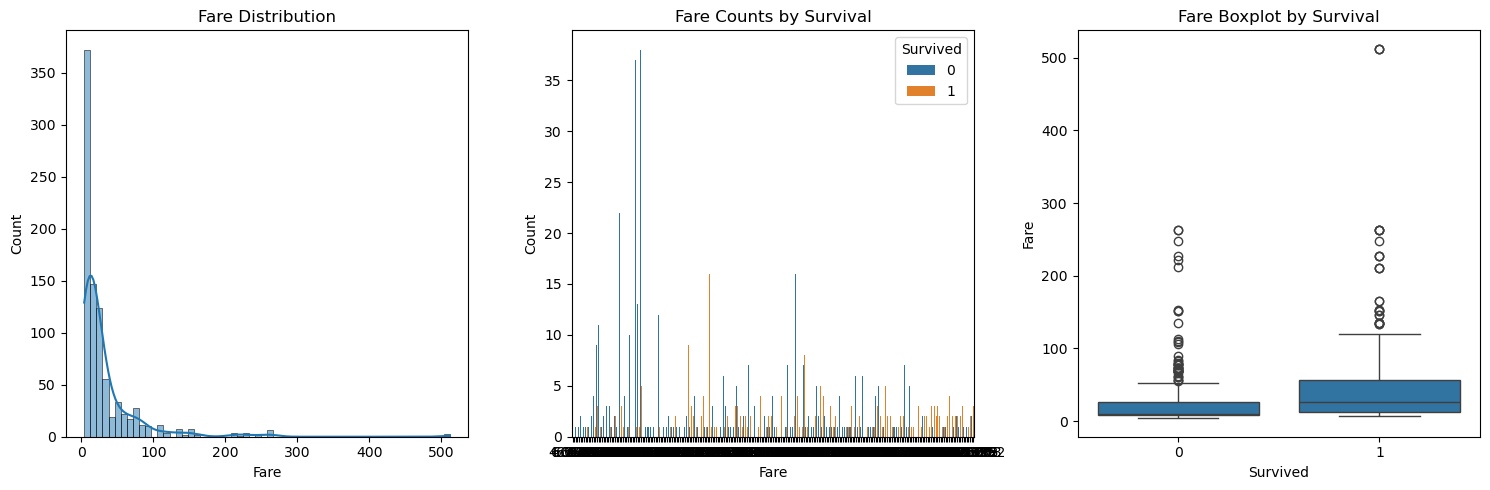

In [9]:
# Visual exploration of numerical features
for i in num_features:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    sns.histplot(explore_ds[i], kde=True, ax=axes[0])
    axes[0].set_title(f"{i} Distribution")
    sns.countplot(data=explore_ds, x=i, hue='Survived', ax=axes[1])
    axes[1].set_title(f"{i} Counts by Survival")
    axes[1].set_xlabel(i)
    axes[1].set_ylabel('Count')
    sns.boxplot(data=explore_ds, x='Survived', y=i, ax=axes[2])
    axes[2].set_title(f"{i} Boxplot by Survival")
plt.tight_layout()
plt.show()

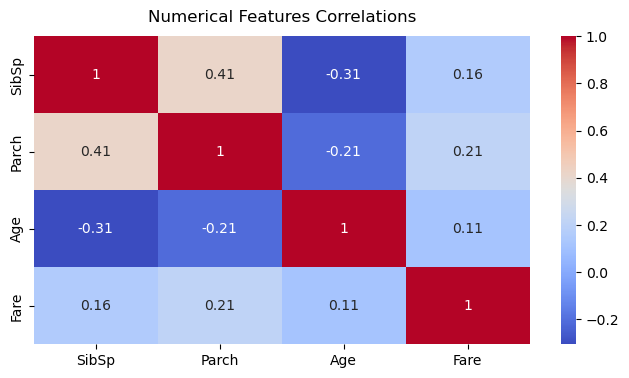

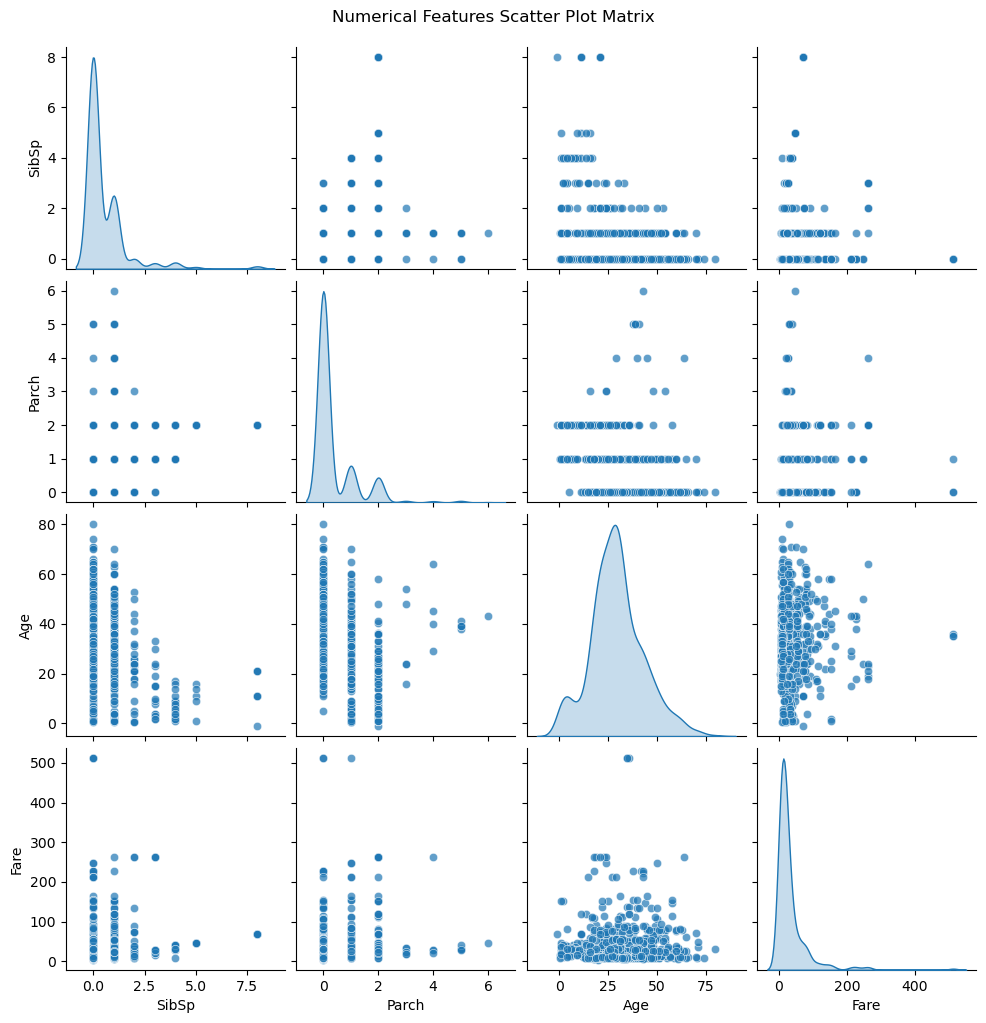

In [10]:
# Correlation analysis for numerical features
correlation_matrix = explore_ds[num_features].corr()
plt.figure(figsize=(len(num_features) * 2, len(num_features)))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Numerical Features Correlations', y=1.02)
plt.show()

# Visualizing relationships
sns.pairplot(explore_ds[num_features], diag_kind='kde', plot_kws={'alpha':0.7})
plt.suptitle('Numerical Features Scatter Plot Matrix', y=1.02)
plt.show()

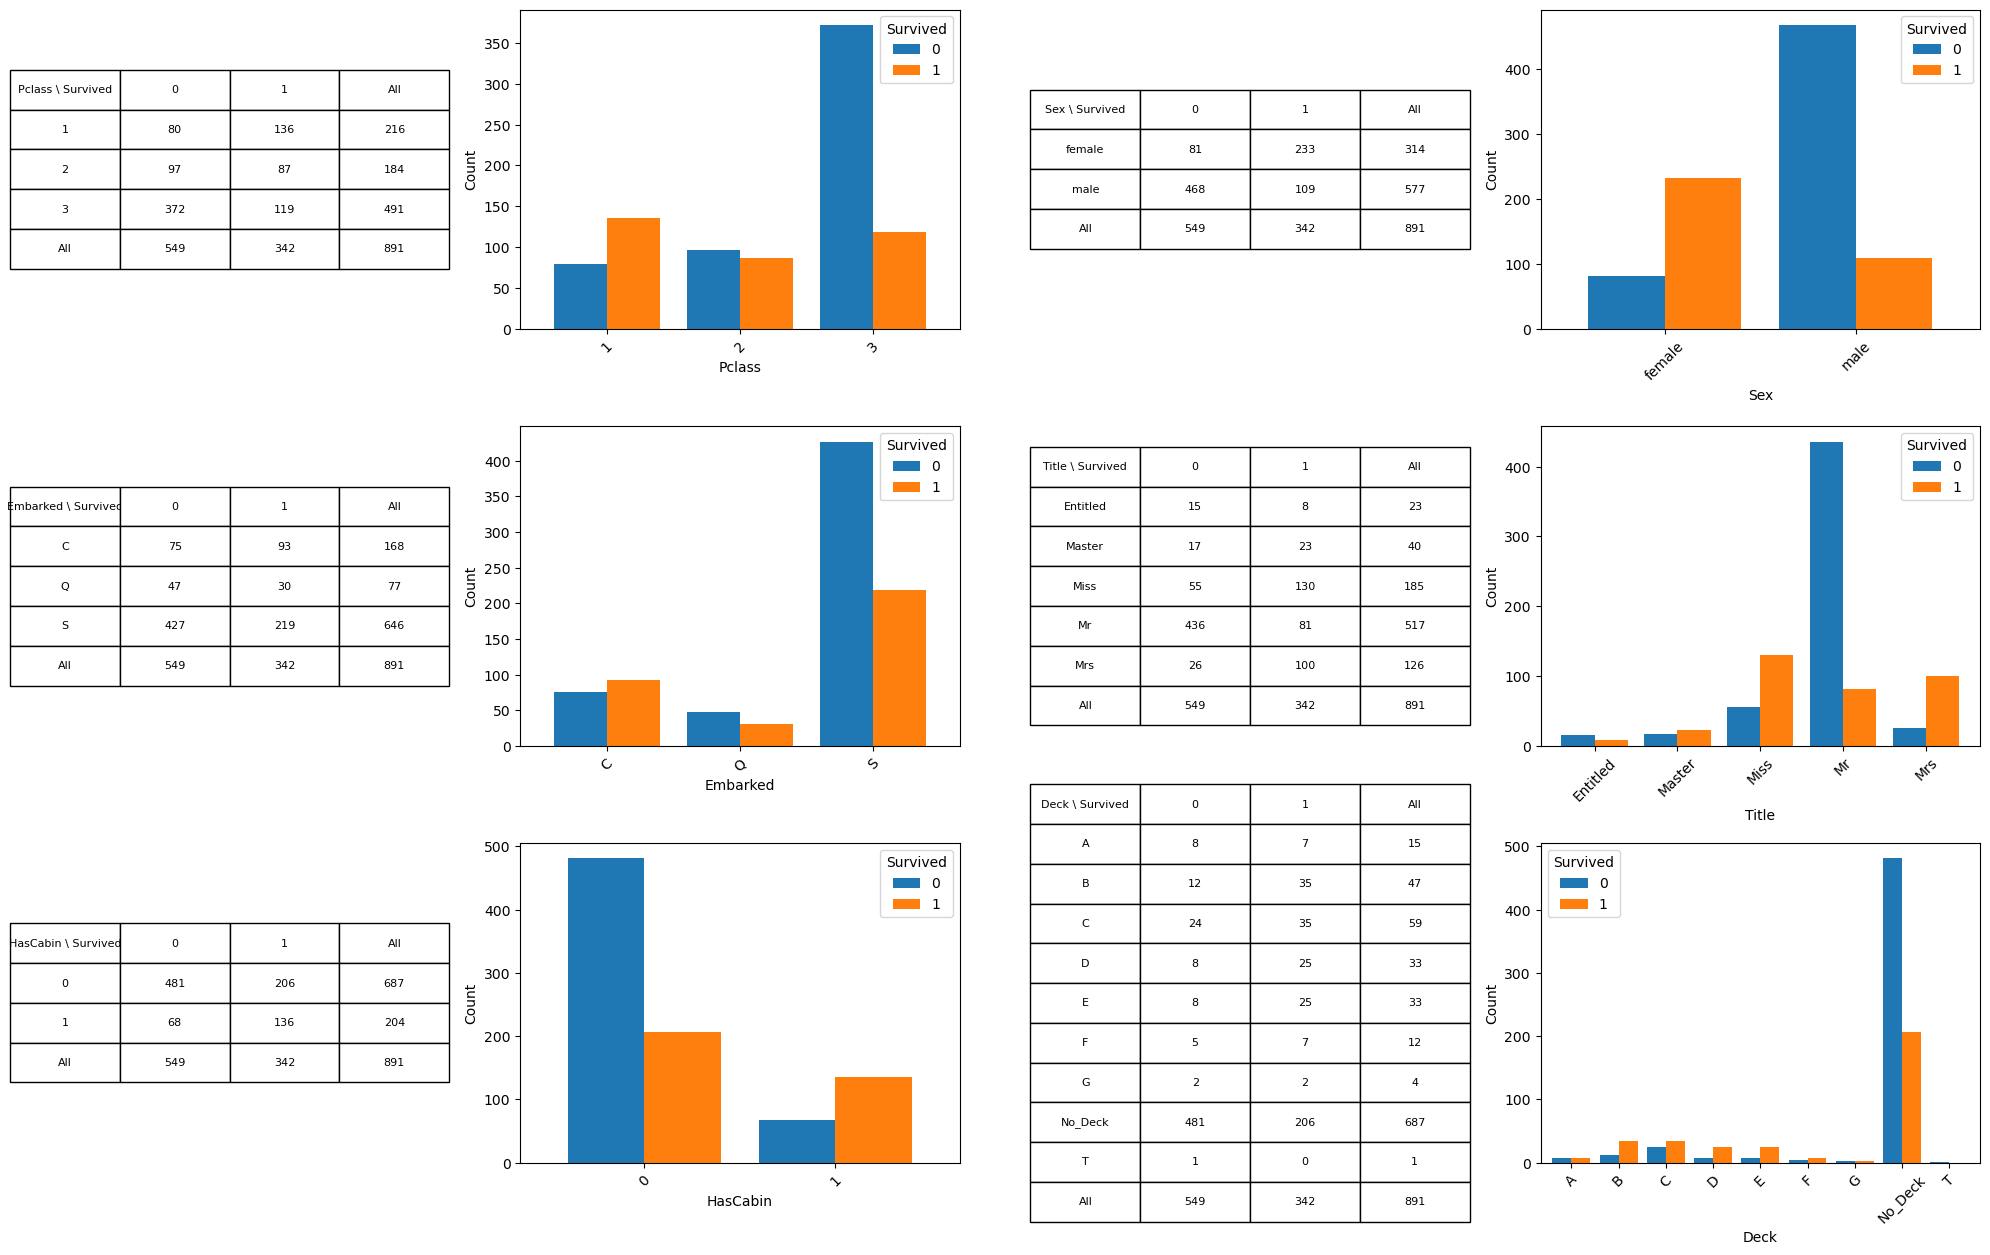

In [11]:
# Create pivot table and barcharts for categorical features
n_features = len(cat_features)
n_rows = (n_features + 2) // 2
n_cols = 4
fig = plt.figure(figsize=(20, 4 * n_rows))

for i, feature in enumerate(cat_features):
    row = i // 2
    col = (i % 2) * 2
    ax_table = plt.subplot2grid((n_rows, n_cols), (row, col))
    ax_bar = plt.subplot2grid((n_rows, n_cols), (row, col + 1))
    pivot = pd.crosstab(explore_ds[feature], target, margins=True)
    ax_table.axis('tight')
    ax_table.axis('off')
    table_data = []
    for idx in pivot.index:
        row_data = [str(idx)] + [str(val) for val in pivot.loc[idx].values]
        table_data.append(row_data)
    
    col_labels = [feature + ' \\ ' + target_name] + [str(col) for col in pivot.columns]
    table = ax_table.table(cellText=table_data,
                           colLabels=col_labels,
                           cellLoc='center',
                           loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2)
    pivot_no_margin = pd.crosstab(explore_ds[feature], target)
    pivot_no_margin.plot(kind='bar', ax=ax_bar, width=0.8)
    ax_bar.set_xlabel(feature)
    ax_bar.set_ylabel('Count')
    ax_bar.tick_params(axis='x', rotation=45)
    ax_bar.legend(title=target_name)

plt.tight_layout()
plt.show()

Based on the above, we will:
1. turn some of our categorical features to one-hot variables,
2. build a few more features.

In [12]:
# Convert to one-hot
combined_ds = pd.get_dummies(combined_ds, columns=['Pclass', 'Embarked', 'Title', 'Deck'], drop_first=False, dtype=int)

In [13]:
# Add more features
combined_ds['TicketMembers'] = combined_ds.groupby(['Ticket'])['PassengerId'].transform(lambda x: x.count())
combined_ds['FamilySize'] = combined_ds['SibSp'] + combined_ds['Parch'] + 1
combined_ds['IsAlone'] = combined_ds.apply(lambda row: 1 if row['TicketMembers']==1 or row['FamilySize']==1 else 0, axis=1)
combined_ds['IsMother'] = combined_ds.apply(lambda row: 1 if ('Mrs.' in row['Name'] and row['Parch']>0) else 0, axis=1)
combined_ds['LogFare'] = combined_ds['Fare'].apply(lambda x: np.log(x))

# Produce new exploration dataset
cat_features = ['IsAlone', 'IsMother']
num_features = ['SibSp', 'Parch', 'Age', 'LogFare', 'TicketMembers', 'FamilySize']
features = cat_features + num_features + ['PassengerId']
explore_ds = combined_ds[combined_ds['IsTrain']==1][features]
explore_ds['Survived'] = train_df['Survived']

### Feature removal
Having exported an exploration dataset, we are going to investigate and drop variables that offer no value to our modelling process:
1. We will remove any constant/quasi constant varriable (variables with no or marginal variability).
2. We will remove duplicate variables (variables with the exact same values). There isn't actually any such variable in our case.

In [14]:
# Remove features with close to 0 variability and create exploration dataset
explore_ds = combined_ds.drop(['PassengerId', 'Name', 'Sex', 'Ticket', 'Fare', 'Cabin', 'estFare', 'estAge'], axis=1)
var = VarianceThreshold(threshold=0.01)
var.fit(explore_ds)
explore_ds = explore_ds[explore_ds['IsTrain']==1]
drop_features = list(explore_ds.columns[~var.get_support()])
drop_features.append('IsTrain')
explore_ds = explore_ds.drop(drop_features, axis=1)
num_features = ['SibSp', 'Parch', 'Age', 'LogFare', 'TicketMembers', 'FamilySize']
cat_features = [col for col in explore_ds.columns if col not in num_features and col not in target_name]

# Find duplicate variables
duplicate_pairs = []
cols = explore_ds.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if explore_ds[cols[i]].equals(explore_ds[cols[j]]):
            duplicate_pairs.append((cols[i], cols[j]))

# Extract the final set of features that we will use in modelling
selected_features = [col for col in explore_ds.columns if col not in duplicate_pairs]

### Prediction Modeling
We choose to build and test 2 different types of models:
1. XGBoost
2. Random Forrest

In [15]:
# Function that evaluates accuracy through CV
def evaluate_model(clf):
    rkf = RepeatedKFold(n_splits=4, n_repeats=30, random_state=random_state)
    scores = cross_val_score(clf, X_val, y_val, cv=rkf, scoring='accuracy')
    print(f"Repeated CV Mean accuracy: {scores.mean()}")

# Function to produce the submission file
def submit_file(pred):
    submission = pd.DataFrame({
        'PassengerId': test_df['PassengerId'],
        'Survived': pred
    })
    submission.to_csv('../submission.csv', index=False)
    print("Submission file created successfully.")

#### Modeling with XGBoost
There have been some suprises while modeling with XGBoost:
- We have tested various feature engineering techniques to find the optimum set of features, but finally it was the original one that had the best performance. Though XGBoost by design use the best variables, this was still interesting.
- The best model had practically no depth!

The score of this approach was a decent 0.78708.

In [16]:
# Extract datasets
model_ds = combined_ds[combined_ds['IsTrain']==1][selected_features]
test_ds = combined_ds[combined_ds['IsTrain']==0][selected_features]
X_train, X_val, y_train, y_val = train_test_split(model_ds, target, test_size=0.3, random_state=random_state)

# Build model
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=1, subsample=0.9, random_state=random_state, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
xgb_pred = xgb_clf.predict(X_val)

# Evaluate and extract submission file
evaluate_model(xgb_clf)
test_xgb = xgb_clf.predict(test_ds)
submit_file(test_xgb)

Repeated CV Mean accuracy: 0.7889303482587064
Submission file created successfully.


#### Modeling with Random Forrests
Random Forrests did work better after removing some features. The best way to do so was with Forward Feature Selection. The model actually performed slightly better than the XGBoost. The score was a decent 0.78947. 

In [17]:
# Though we could re-use the previous datasets, this was not always the case during the development and just to be on the safe side I reset
selected_features = [col for col in explore_ds.columns if col not in duplicate_pairs]
X_train, X_test, y_train, y_test = train_test_split(explore_ds[selected_features], target, test_size=0.3, random_state=random_state)

# Apply FFS and extract the optimum feature set
sfs = SFS(
    estimator=RandomForestClassifier(n_estimators=100, random_state=random_state),
    n_features_to_select=0.8,
    direction='forward',
    scoring='roc_auc',
    cv=4, n_jobs=12
)
sfs = sfs.fit(X_train, y_train)
selected_features = sfs.get_feature_names_out()

In [18]:
# Extract datasets for new dataset
model_ds = combined_ds[combined_ds['IsTrain']==1][selected_features]
test_ds = combined_ds[combined_ds['IsTrain']==0][selected_features]
X_train, X_val, y_train, y_val = train_test_split(model_ds, target, test_size=0.3, random_state=random_state)

# Build model
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=random_state)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_val)

# Evaluate and extract submission file
evaluate_model(rf_clf)
test_rf = rf_clf.predict(test_ds)
submit_file(test_rf)

Repeated CV Mean accuracy: 0.7915422885572139
Submission file created successfully.


#### Ensembling the models
What proved to be more interesting was the ensembling of the models. Using the predictions of the 2 models, we produced another one that was based on them and that would use a simple rule: there will be a positive prediction only if both models are positive, in any other case prediction would negative. For example, if both Random Forrest and XGBoost predicted that the passenger will survive, we set the value to 1. If any of the models was not optimistic, we would set the value to 0. Interestigly, the result was better that the results of the individual models (to an even more decent score of 0.79425). This was my final submission to the competition.

In [20]:
# Build a combined dataset, then the combined value
ensemble_ds = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'xgb': test_xgb, 'rf': test_rf})
ensemble_ds['both'] = np.minimum(test_xgb, test_rf)

# Extract submission file
submit_file(ensemble_ds['both'])

Submission file created successfully.
